<a href="https://colab.research.google.com/github/USF-IMARS/obis-api-live-demos/blob/main/2026-usf-moore-mbon/01_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text boxes indicate the AI prompts recommended to generate the code below. Remember that most AIs are stochastic; re-using a prompt could produce a completely different result.
Function documentations are copied from https://github.com/iobis/pyobis/tree/main/pyobis

----------------------------------

In [1]:
# install the latest pyobis from github
!pip install -q git+https://github.com/iobis/pyobis.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.


Get the aphiaID for taxon Euphausiacea using the pyobis function described below and store it as a variable named `aphia_id`.

    """
    Get taxon records.

    :param scientificname: [String,Array] One or more scientific names from the
        OBIS backbone. All included and synonym taxa are included in the search
    :param cache: [bool, optional] Whether to use caching. Defaults to True.
    :return: Dictionary with keys: [
        'scientificName', 'scientificNameAuthorship', 'taxonID', 'ncbi_id',
        'taxonRank', 'taxonomicStatus', 'acceptedNameUsage',
        'acceptedNameUsageID', 'is_marine', 'kingdom', 'phylum', 'subphylum',
        'superclass', 'class', 'subclass', 'superorder', 'order', 'kingdomid',
        'phylumid', 'subphylumid', 'superclassid', 'classid', 'subclassid',
        'superorderid', 'orderid', 'vernacularNames'
    ]

    Usage::

        from pyobis import taxa

        # With caching enabled (default)
        query = taxa.search(scientificname='Mola mola')
        aphia_id = result['results'][0]['taxonID']
        
        # With caching disabled
        query = taxa.search(scientificname='Mola mola', cache=False)
        aphia_id = result['results'][0]['taxonID']

        # Get the data
        query.data # return the fetched data
        query.api_url # get the OBIS API URL for the built query
        query.mapper_url # get the OBIS Mapper URL (if it exists)
    """

In [8]:
import pyobis

# Get taxon records for 'Euphausiacea'
query = pyobis.taxa.search(scientificname='Euphausiacea')

# Execute the query and extract the 'taxonID' as aphia_id
result = query.execute()
aphia_id = result['results'][0]['taxonID']

print(f"The AphiaID for Euphausiacea is: {aphia_id}")

The AphiaID for Euphausiacea is: 1128


Use the OBIS API via the pyOBIS library's `pyobis.occurrences.search()` described below to download all occurrences of the WoRMS aphiaID taxon stored as a variable named `aphia_id` that are in the area around the Azores into a dataframe named `df`.

    """
    Search OBIS occurrences

    :param taxonid: [Fixnum] An OBIS occurrence identifier
    :param scientificname: [String,Array] One or more scientific names from the
        OBIS backbone. All included and
        synonym taxa are included in the search.
    :param year: Removed in v3 API. [Fixnum] The 4 digit year. A year of 98
        will be interpreted as AD 98. Supports range queries,
        smaller,larger (e.g., '1990,1991', whereas '1991,1990' wouldn't work)
    :param geometry: [String] Well Known Text (WKT). A WKT shape written
        as either POINT, LINESTRING, LINEARRING
        or POLYGON.
        Example of a polygon: ((30.1 10.1, 10 20, 20 40, 40 40, 30.1 10.1)) would
        be queried as https://api.obis.org/v3/occurrence?geometry=POLYGON%28%2830.1+10.1%2C+10+20%2C+20+40%2C+40+40%2C+30.1+10.1%29%29
    :param nodeid: [String] Node UUID
    :param taxonid: Prev. aphiaid [Fixnum] An Aphia id. This is listed as
        the `worms_id` in `taxa`/`taxon` results
    :param datasetid: Prev. resourceid [Fixnum] A resource id
    :param startdate: [Fixnum] Start date, formatted as YYYY-MM-DD
    :param enddate: [Boolean] End date, formatted as YYYY-MM-DD
    :param startdepth: [Fixnum] Start depth, in meters. Depth below sea level are treated
        as positive numbers.
    :param enddepth: [Boolean] End depth, in meters. Depth below sea level are treated
        as positive numbers.
    :param flags: Prev. qc [String] Quality control flags
    :param fields: [String] Comma separated list of field names. Leave blank to include all.
        For fetching records more than 10k, must specify 'id' explicitly too.
    :param size: [Fixnum] Number of results to return. Default: All records
    :param offset: [Fixnum] Start at record. Default: 0
    :param mof: [Boolean] Include MeasurementOrFact records, true/false.
        Default: 0
    :param hasextensions: [String] Extensions that need to be present
        (e.g. MeasurementOrFact, DNADerivedData).
    :param cache: [bool, optional] Whether to use caching. Defaults to True.
    :return: A pandas dataframe of taxon occurrences.

    Usage::

        from pyobis import occurrences
        df = occurrences.search(scientificname = 'Mola mola').execute()

        # Many names
        df = occurrences.search(scientificname = ['Mola', 'Abra', 'Lanice', 'Pectinaria']).execute()

        # Use paging parameters (limit and start) to page.
        # Note the different results for the two queries below.
        df = occ.search(scientificname = 'Mola mola', offset=0, size=10)
        df = occ.search(scientificname = 'Mola mola', offset=10, size=10)

        # Search on a bounding box
        ## in well known text format
        df = occurrences.search(
            geometry='POLYGON((30.1 10.1, 10 20, 20 40, 40 40, 30.1 10.1))',
            size=20
        ).execute()

        from pyobis import taxa

        res = taxa.search(scientificname='Mola mola').execute()['results'][0]
        df = occurrences.search(
            obisid=res['taxonID'],
            geometry='POLYGON((30.1 10.1, 10 20, 20 40, 40 40, 30.1 10.1))',
            size=20
        ).execute()
        df = occurrences.search(
            aphiaid=res['worms_id'],
            geometry='POLYGON((30.1 10.1, 10 20, 20 40, 40 40, 30.1 10.1))',
            size=20
        ).execute()

        # Get mof response as a pandas dataframe
        df = occurrences.search(
            scientificname="Abra", mof=True, hasextensions="MeasurementOrFact", size=100
            ).execute()
    """  # noqa: E501


In [15]:
import pandas as pd

# Define the bounding box for the Azores
# Min Longitude, Min Latitude, Max Longitude, Max Latitude
# Azores: -31.3 to -23.5 Longitude, 36.9 to 40.0 Latitude
azores_geometry = 'POLYGON((-31.3 36.9, -23.5 36.9, -23.5 40.0, -31.3 40.0, -31.3 36.9))'

# Search for occurrences using the aphia_id and Azores geometry
# The parameter `taxonid` in pyobis.occurrences.search() takes the AphiaID
occurrences_query = pyobis.occurrences.search(
    taxonid=aphia_id,
    geometry=azores_geometry
)

# Execute the query to fetch the data
occurrences_result = occurrences_query.execute()

# Convert the results to a pandas DataFrame
df = pd.DataFrame(occurrences_result)

print(f"Downloaded {len(df)} occurrences for Euphausiacea in the Azores region.")
display(df.head())

Downloaded 924 occurrences for Euphausiacea in the Azores region.


,basisOfRecord,catalogNumber,class,classid,datasetName,date_end,date_mid,date_start,date_year,decimalLatitude,...,speciesid,specificEpithet,taxonRank,taxonomicStatus,verbatimLocality,higherClassification,identificationRemarks,parentEventID,verbatimIdentification,waterBody
0,PreservedSpecimen,91BB-21-87,Malacostraca,1071,CPR,1.825632e+11,1.825632e+11,1.825632e+11,1975.0,39.0833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PreservedSpecimen,42BC-35-88,Malacostraca,1071,CPR,4.354560e+10,4.354560e+10,4.354560e+10,1971.0,39.5100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PreservedSpecimen,383BC-45-88,Malacostraca,1071,CPR,1.045786e+12,1.045786e+12,1.045786e+12,2003.0,37.3701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PreservedSpecimen,41BC-35-88,Malacostraca,1071,CPR,4.008960e+10,4.008960e+10,4.008960e+10,1971.0,38.9867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HumanObservation,48BC-25-88,Malacostraca,1071,NaN,NaN,NaN,NaN,NaN,38.0600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Visualize the range of `date_year`s in the dataframe `df`.

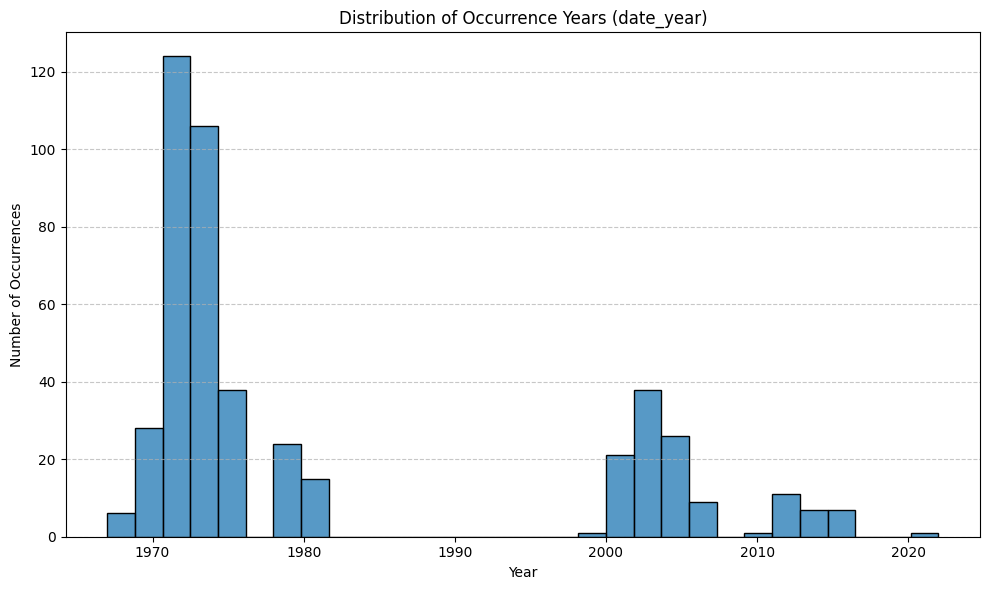

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date_year' exists and is of a numeric type
if 'date_year' in df.columns:
    # Drop rows where 'date_year' is NaN before plotting
    df_plot = df.dropna(subset=['date_year'])

    plt.figure(figsize=(10, 6))
    sns.histplot(df_plot['date_year'], kde=False, bins=30) # Using histplot for distribution
    plt.title('Distribution of Occurrence Years (date_year)')
    plt.xlabel('Year')
    plt.ylabel('Number of Occurrences')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("The 'date_year' column does not exist in the DataFrame.")

Visualize the geospatial distribution of rows using `decimalLatitude` and `decimalLongitude` columns from dataframe `df`. Include a basemap. Aggregate results into hexagonal bins if displaying many points.

In [19]:
import folium
from folium.plugins import HeatMap

# Ensure 'decimalLatitude' and 'decimalLongitude' columns exist and are not null
if 'decimalLatitude' in df.columns and 'decimalLongitude' in df.columns:
    # Drop rows with NaN values in 'decimalLatitude' or 'decimalLongitude' for plotting
    df_geo_plot = df.dropna(subset=['decimalLatitude', 'decimalLongitude']).copy() # Use .copy() to avoid SettingWithCopyWarning

    # Calculate the center of the Azores region for the map
    center_lat = df_geo_plot['decimalLatitude'].mean()
    center_lon = df_geo_plot['decimalLongitude'].mean()

    # Create a Folium map centered on the Azores
    m = folium.Map(location=[center_lat, center_lon], zoom_start=7)

    # Prepare data for HeatMap: list of [latitude, longitude]
    heat_data = [[row['decimalLatitude'], row['decimalLongitude']] for index, row in df_geo_plot.iterrows()]

    # Add HeatMap layer to the map
    HeatMap(heat_data).add_to(m)

    # Display the map
    display(m)
else:
    print("One or both of 'decimalLatitude' and 'decimalLongitude' columns are not present or contain only NaN values in the DataFrame.")